<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
پزشک قطعه‌ها
</font>
</h1>

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مقدمه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این تمرین قصد داریم تا آستانه گذاری را روی تصاویر پزشکی بررسی کنیم و کاربردهای مختلف آنرا مشاهده کنیم.
</font>
</p>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش اول: قطعه‌بندی اسکلت
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش می‌خواهیم با استفاده از آستانه‌گذاری، اسکلت موجود در تصویر را از پیش‌زمینه متمایز کنیم. در ادامه با جزئیات این بخش بیشتر آشنا خواهیم شد.
</font>
</p>

---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را بصورت خاکستری بخوانید.
<br>
Data/Skeleton.tif
</font>
</p>


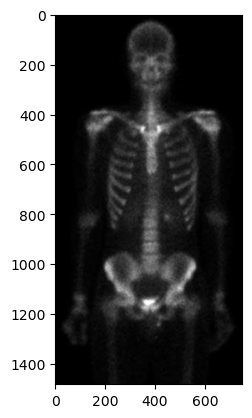

In [3]:
original_image = cv2.imread("Data/Skeleton.tif", cv2.IMREAD_GRAYSCALE)
plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: تشخیص آستانه
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این قسمت تصویر اسکلت را با استفاده از روش اتسو قطعه‌بندی کنید. ابتدا آستانه را پیدا کنید و سپس تصویر قطعه‌بندی شده را ذخیره کنید.
</font>
</p>

In [21]:
otsu_threshold, image_segment = cv2.threshold(original_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
otsu_threshold

45.0

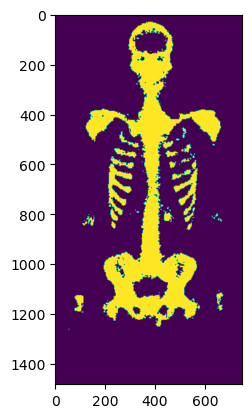

In [22]:
plt.imshow(image_segment)

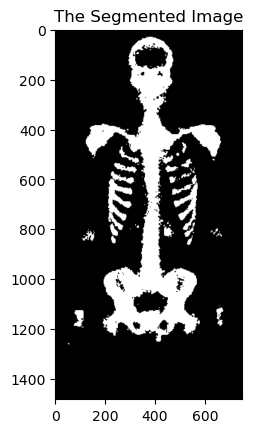

9.87339207875166

In [23]:
threshold = 44
_, image_seg = cv2.threshold(original_image, threshold, 255, cv2.THRESH_BINARY)

plt.imshow(cv2.cvtColor(image_seg, cv2.COLOR_BGR2RGB))
plt.title("The Segmented Image")
plt.show()

solution = cv2.imread('segment_skeleton.tif', cv2.IMREAD_GRAYSCALE)
cv2.PSNR(solution, image_seg)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: ذخیره تصویر</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تصویر قطعه‌بندی شده را با نام زیر ذخیره کنید. دقت کنید که تصویر را حتما به شکل RGB ذخیره کنید.
<br>
segment_skeleton.tif
</font>
</p>

In [24]:
cv2.imwrite('segment_skeleton.tif', cv2.cvtColor(image_seg, cv2.COLOR_BGR2RGB))

True

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش دوم: قطعه‌بندی قفسه سینه
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش می‌خواهیم که عکس x-ray قفسه سینه یک انسان را قطعه‌بندی کنیم. در ادامه با مراحل اینکار آشنا خواهید شد.
</font>
</p>

---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را بصورت خاکستری بخوانید.
<br>
Data/chest.webp
</font>
</p>


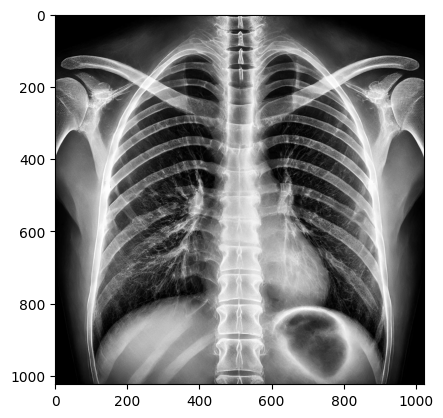

In [6]:
image = cv2.imread("Data/chest.webp", cv2.IMREAD_GRAYSCALE)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: اعمال آستانه‌گذاری باندی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
تصویر را با توجه به باندهای زیر آستانه‌گذاری کنید.
<br>
</font>
</p>

$$
D = \left\{ (0, 50), (51, 100), (101, 150), (151, 200), (201, 255) \right\}
$$

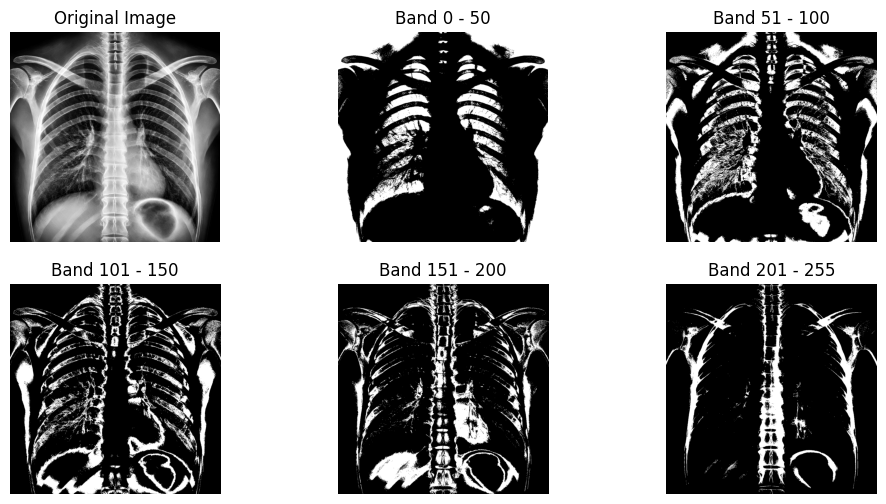

In [7]:

bands = [(0, 50), (51, 100), (101, 150), (151, 200), (201, 255)]
band_images = []


for (lower, upper) in bands:
    mask = cv2.inRange(image, lower, upper)
    band_images.append(mask)


plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

for i, band_img in enumerate(band_images):
    plt.subplot(2, 3, i + 2)
    plt.imshow(band_img, cmap='gray')
    plt.title(f"Band {bands[i][0]} - {bands[i][1]}")
    plt.axis('off')

plt.show()

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله چهارم: ذخیره‌سازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
خروجی هر باند را با نام‌های زیر ذخیره کنید. دقت کنید که تصاویر را به شکل RGB ذخیره کنید.
<br>
chest_0_50.jpg
<br>
chest_51-100.jpg
<br>
chest_101_150.jpg
<br>
chest_151_200.jpg
<br>
chest_201_255.jpg
</font>
</p>

In [8]:
file_name = ['chest_0_50.jpg', 'chest_51_100.jpg', 'chest_101_150.jpg', 'chest_151_200.jpg', 'chest_201_255.jpg']

for i in range(len(file_name)):
    image = cv2.cvtColor(band_images[i], cv2.COLOR_BGR2RGB)
    cv2.imwrite(file_name[i], image)

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پنجم: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [9]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "segment_skeleton.tif", 'chest_0_50.jpg', 'chest_51_100.jpg', 'chest_101_150.jpg', 'chest_151_200.jpg', 'chest_201_255.jpg']
compress(file_names)

File Paths:
['notebook.ipynb', 'segment_skeleton.tif', 'chest_0_50.jpg', 'chest_51_100.jpg', 'chest_101_150.jpg', 'chest_151_200.jpg', 'chest_201_255.jpg']
